In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev, median
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

filename = "../data/packet-warm_ped_150cycles_480s_7tiles_2025_12_22.hdf5"


# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# the following values are just being initialized to zero
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
first_tile = True

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def skewness(data, chip, chan):
    """
    Calculate sample skewness (Fisher-Pearson).
    """
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 3:
        raise ValueError(f"At least 3 data points required for skewness. Channel {chip}-{chan} only had {n}.")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)  
    m3 = np.mean((data - mean) ** 3)
    
    # Fisher-Pearson coefficient of skewness
    if n > 3 and std_dev > 0:
        skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / (std_dev ** 3))
    else:
        print(f'\nSkew problem Chip-Channel {chip}-{chan}. Stdev = {std_dev}, # pkts {n}')
        skew = 0        
        
    return skew

def kurtosis(data, chip, chan):
    """
    Calculate sample excess kurtosis (Fisher definition).
    """
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 4:
        raise ValueError(f"At least 4 data points are required for kurtosis. Channel {chip}-{chan} only had {n}")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)
    m4 = np.mean((data - mean) ** 4)
    
    # Excess kurtosis (subtract 3 to make normal distribution = 0)
    if n > 4 and std_dev > 0:
        kurt = (n * (n + 1) * m4 / (std_dev ** 4) - 3 * (n - 1) ** 2) / ((n - 1) * (n - 2) * (n - 3))
    else:
        print(f'Kurtosis problem Chip-Channel {chip}-{chan}. Stdev = {std_dev}, # pkts {len(data)}')
        kurt = 0        
    
    return kurt

In [4]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan
    global chip_serial_number, first_tile
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    
    bad_std, bad_mean, high_skew, high_kurtosis = 0, 0, 0,0
    bad_std_list, bad_mean_list, high_skew_list, high_kurtosis_list = [], [], [], []
    mean_adc_list, std_adc_list, skew_adc_list, kurtosis_adc_list = [], [], [], []
    unique_chips  = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    debug_count = 0

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    if first_tile:
        npkts         = len(data_pkts) 
        print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking") 
        print(f"\tIO_channels in file: \n\t{[int(x) for x in unique_io_channels]}")
        first_tile = False

    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    print(f"\n\n############################ Checking Tile {tile} ###################################")
    print(f'Run Statistics for Tile {tile}:')    
    print(f'\tio_channels enabled for tile {tile}: {enabled_io_channels}')
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    # identify chips on this tile with data packets
    unique_chips = list(dict.fromkeys(data_pkts['chip_id'][:]))    
    
    npkts = len(data_pkts) 

    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
    
#########################################################
# identify misnumbered chips, out of range adc datawords
##########################################################
    
    data_chips = data_pkts['chip_id'][:]
    data_fifo  = data_pkts['shared_fifo'][:]
    nfifo_full = data_fifo.tolist().count(3)

    #print(f'Tile {tile}: {nfifo_full} packets registered shared FIFO full')
    
    unique_chips = list(dict.fromkeys(data_chips))

    print(f'\t{len(unique_chips)} chips were recorded from Tile {tile}')    
    
    for chip in range(11,171):

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        chip_adc   = chip_pkts['dataword'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))
        
        # create list used to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])
        
        mode_adc_chip = mode(chip_adc)
        
        # determine various channel attributes (# packets, mean adc, stdev adc, skew, kurtosis)
        for chan in range(64):
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']

            # count the # of packets by channel
            npkt = len(chan_pkts)
            ndata_by_channel[chip][chan] = npkt
            ndata_by_channel_list.append(npkt)

            if npkt==0:
                continue
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]

            # calculate acd mean and stdev. Identify channels with means or stdev outside of acceptible ranges
            if len(non_zero_chan_adc) > 1:
               
                mean_adc = mean(non_zero_chan_adc.tolist())
                mean_adc_list.append(mean_adc)
                # the acceptible channel mean range is the chip's mean dataword +/- 50
                if mean_adc > mode_adc_chip + 50 or mean_adc < mode_adc_chip - 50:
                    bad_mean_list.append(str(f"{chip}-{chan}"))
                    bad_mean +=1

                std_adc = stdev(non_zero_chan_adc.tolist())
                std_adc_list.append(std_adc)
                # the acceptible stdev range is [0.01, 2]                
                if std_adc > 2 or std_adc < 0.01:
                    bad_std +=1
                    bad_std_list.append(str(f"{chip}-{chan}"))

                skew_adc, kurtosis_adc = 0, 0 
                skew_adc = skewness(non_zero_chan_adc.tolist(), chip, chan)
                skew_adc_list.append(skew_adc)
                # an abs(skew) < 2 indicates datawords are distributed evenly around their mean
                if abs(skew_adc) > 2:
                    high_skew +=1
                    high_skew_list.append(str(f"{chip}-{chan}"))


                kurtosis_adc = kurtosis(non_zero_chan_adc.tolist(), chip, chan)
                kurtosis_adc_list.append(kurtosis_adc)
                    
            # an abs(kurtosis) < 2 indicates the distributions have tails consistent with a normal distribution
                if abs(kurtosis_adc) > 2:
                    high_kurtosis +=1
                    high_kurtosis_list.append(str(f"{chip}-{chan}"))            
            
            elif verbose:
                print(f"channel {chip}-{chan} had no packets")
                
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    mode_mean_tile = mode(mean_adc_list)
    mean_stdev_tile = mean(std_adc_list)

    print(f'\tTile {tile} most common # of packets in a chip {npkts_mode}, Most common # of packets in a channel {npkts_mode_chan}')
    
    print(f'\n{bad_std} channels ({bad_std/10240:.4f}%) had adc stdev outside of range [.01, 2] on Tile {tile}: \n{bad_std_list}\n')
    print(f'\n{bad_mean} channels ({bad_mean/10240:.4f}%) had adc mean > mode +/- 50 on Tile {tile}: \n{bad_mean_list}\n')
    print(f'\n{high_skew} channels ({high_skew/10240:.4f}%) had adc skew > 2 on Tile {tile}: \n{high_skew_list}\n')    
    print(f'\n{high_kurtosis} channels ({high_kurtosis/10240:.4f}%) had adc kurtosis > 2 on Tile {tile}: \n{high_kurtosis_list}\n') 
    print(f'\n{ndata_by_channel_list.count(0)} channels had no packets\n')  
  
    fig, axis = plt.subplots(1,2, figsize=(10, 4))
    plt.suptitle(f'Tile #{tile} ({chip_serial_number}): Zoom into Distributions of Mean (left) & Stdev (right) Dataword by Channel\n{bad_mean} chans mean > mode +/- 50                       {bad_std} chans stdev ouside [.01,2]')

    axis[0].hist(mean_adc_list, bins = int(max(mean_adc_list)))
    #axis[0].set_title(f'Zoom into Mean ADC Dataword')
    axis[0].set_xlabel(f'Mean ADC Dataword (zoom into distribution)')
    axis[0].set_yscale('log')
    axis[0].set_xlim(mode_mean_tile -50, mode_mean_tile +50)
    axis[0].text(mode_mean_tile -40, 100, f'Mode = {mode_mean_tile:.0f}', color='red', style='italic')    
    axis[0].axvline(x = mode_mean_tile, color='r', linestyle='--')    
    axis[0].set_ylabel(f'Channel Count')            

    axis[1].hist(std_adc_list, bins = int(max(std_adc_list))*10)
    #axis[1].set_title(f'Zoom into Stdev ADC Dataword')
    axis[1].set_xlabel(f'Stdev ADC Dataword')
    axis[1].set_xlim(0,5)
    axis[1].text(2, 100, f'Mean = {mean_stdev_tile:.1f}', color='red', style='italic')    
    axis[1].axvline(x = mean_stdev_tile, color='r', linestyle='--')      
    axis[1].set_ylabel(f'Channel Count')
    axis[1].set_yscale('log')
    plt.show                

    fig, axis = plt.subplots(1,3, figsize=(12, 4))
    plt.suptitle(f'Tile #{tile} ({chip_serial_number}): Pedestal Skew (left),           Kurtosis (middle),                      # Pkts by Channel (right)\n{high_skew} chans skew > 2\
                                  {high_kurtosis} chans kurtosis > 2                              {ndata_by_channel_list.count(0)} channels had 0 packets')
    
    axis[0].hist(skew_adc_list, color = 'c')
    #axis[0].set_title(f'ADC Dataword Skew by Channel (Mode {mode_mean_tile:.0f})\n{high_skew} channels had skew > 2\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'ADC Dataword Skew')
    axis[0].set_yscale('log')
    axis[0].axvline(x = -2, color='r', linestyle='--') 
    axis[0].axvline(x =  2, color='r', linestyle='--') 
    axis[0].set_ylabel(f'Channel Count')
    
    xmax = max(2.2, max(kurtosis_adc_list))
    
    axis[1].hist(kurtosis_adc_list, color = 'm')
    #axis[1].set_title(f'ADC Dataword Kurtosis by Channel (Mode {mode_mean_tile:.0f})\n{high_kurtosis} channels had kurtosis > 2\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlabel(f'ADC Dataword Kurtosis')
    axis[1].set_yscale('log')
    axis[1].set_xlim(0,xmax)    
    axis[1].axvline(x =  2, color='r', linestyle='--') 
    #axis[1].set_ylabel(f'Channel Count')    
    
    axis[2].hist(ndata_by_channel_list)
    #axis[2].set_title(f'# of Datawords by Channel\n{ndata_by_channel_list.count(0)} channels had no packets\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[2].set_xlabel(f'# of Packets')
    axis[2].set_yscale('log')
    #axis[2].set_ylabel(f'Channel Count')
    plt.show 
    
    return 

Run Statistics for Data File ../data/packet-warm_ped_150cycles_480s_7tiles_2025_12_22.hdf5:
	34,964,741 data packets for tile 1 arriving at an average rate of 74552 pkts/s over 469s of data taking
	IO_channels in file: 
	[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23, 25, 26, 27]


############################ Checking Tile 1 ###################################
Run Statistics for Tile 1:
	io_channels enabled for tile 1: [1, 2, 3, 4]
	161 chips were recorded from Tile 1

Skew problem Chip-Channel 40-30. Stdev = 0.0, # pkts 488
Kurtosis problem Chip-Channel 40-30. Stdev = 0.0, # pkts 488

Skew problem Chip-Channel 50-12. Stdev = 0.0, # pkts 488
Kurtosis problem Chip-Channel 50-12. Stdev = 0.0, # pkts 488

Skew problem Chip-Channel 50-14. Stdev = 0.0, # pkts 488
Kurtosis problem Chip-Channel 50-14. Stdev = 0.0, # pkts 488
	Tile 1 most common # of packets in a chip 31219, Most common # of packets in a channel 488

41 channels (0.0040%) had adc stdev outside of range

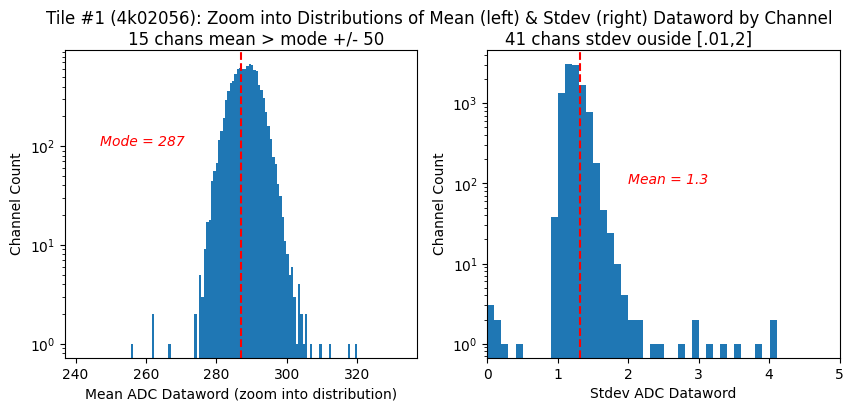

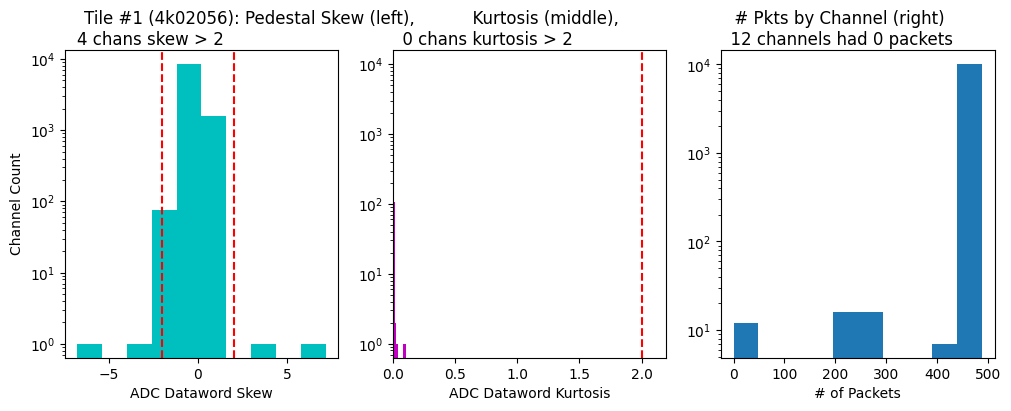

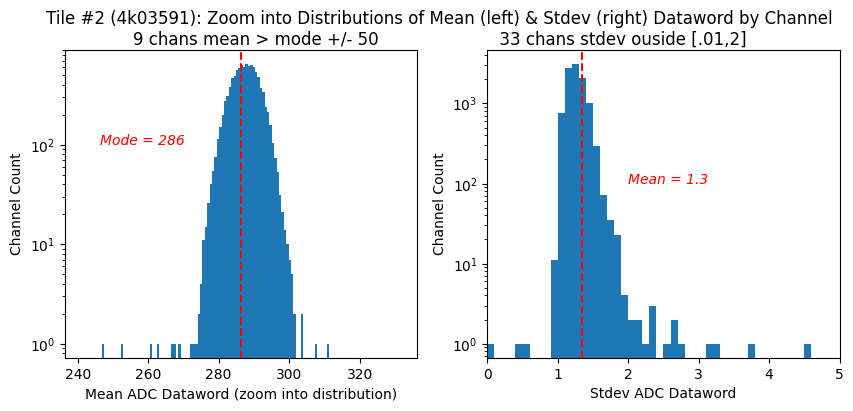

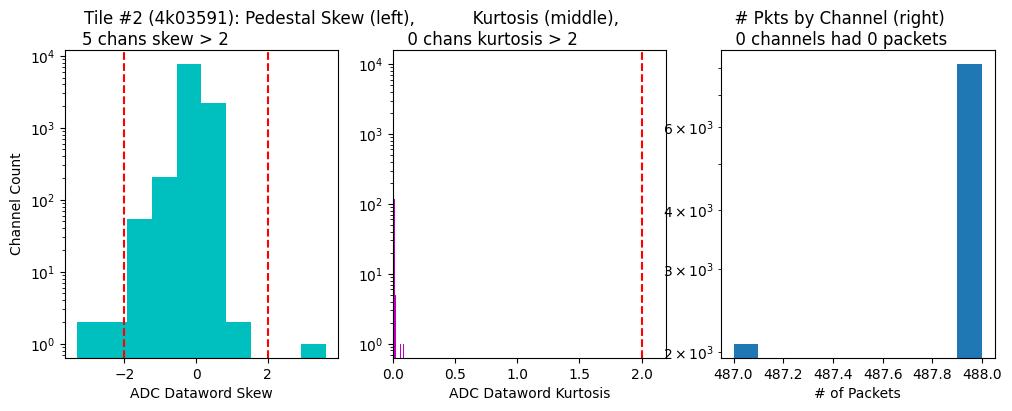

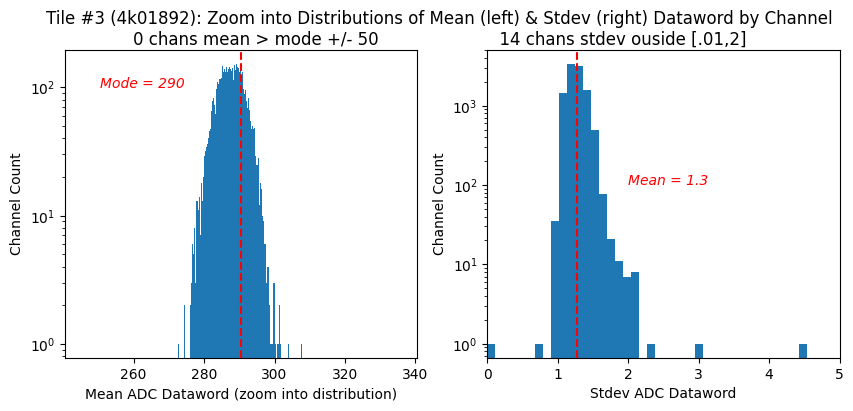

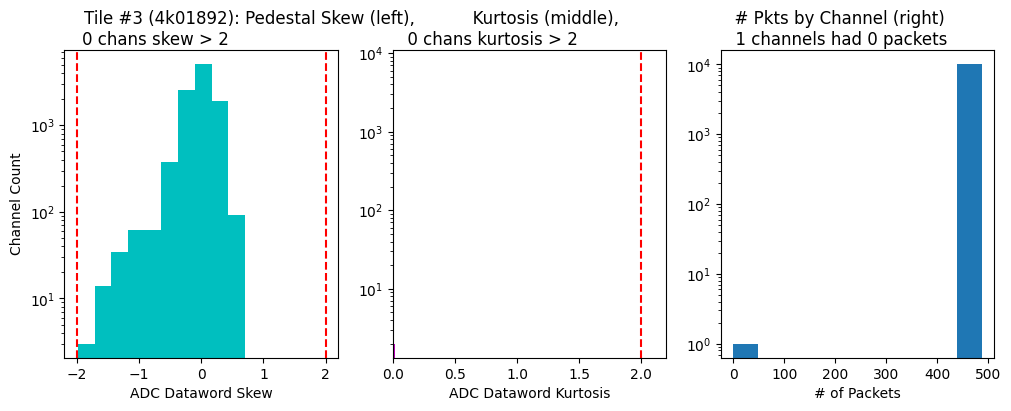

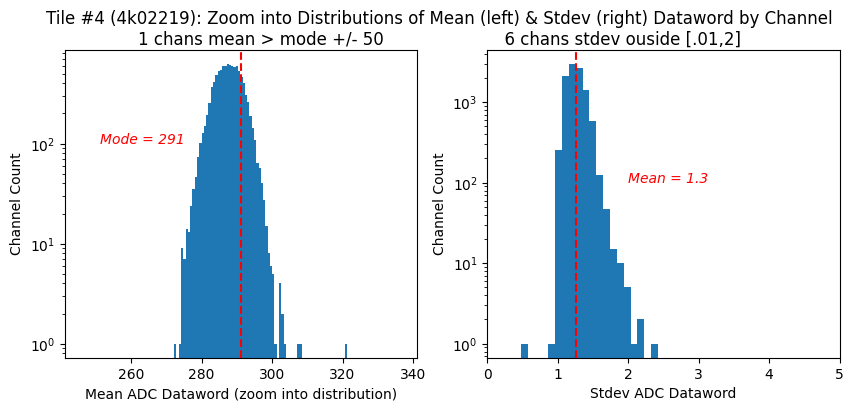

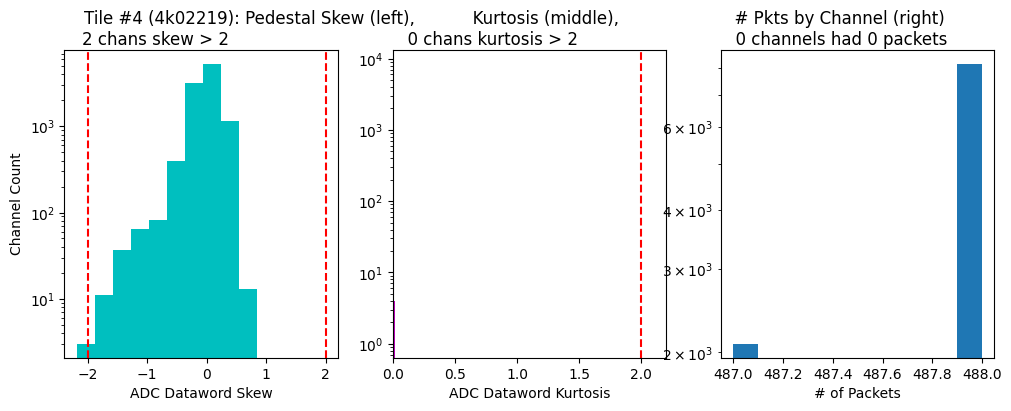

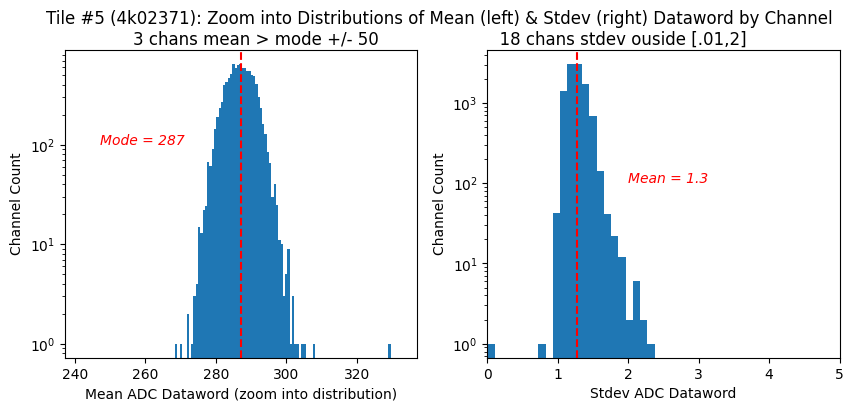

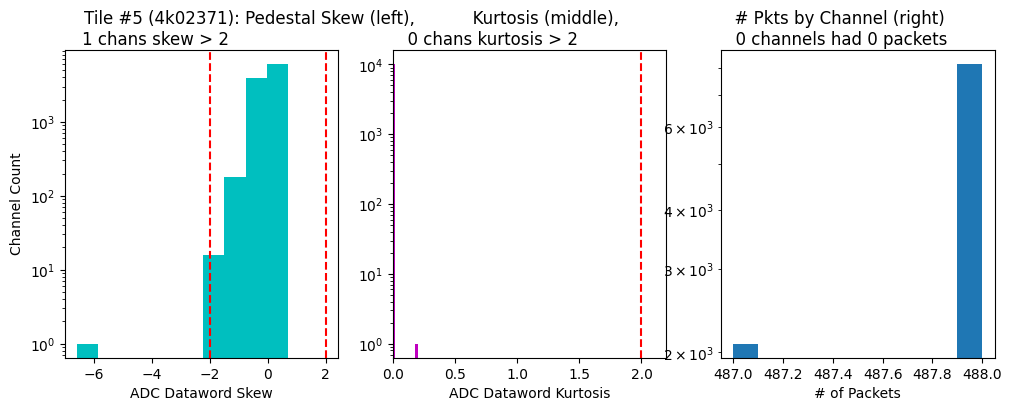

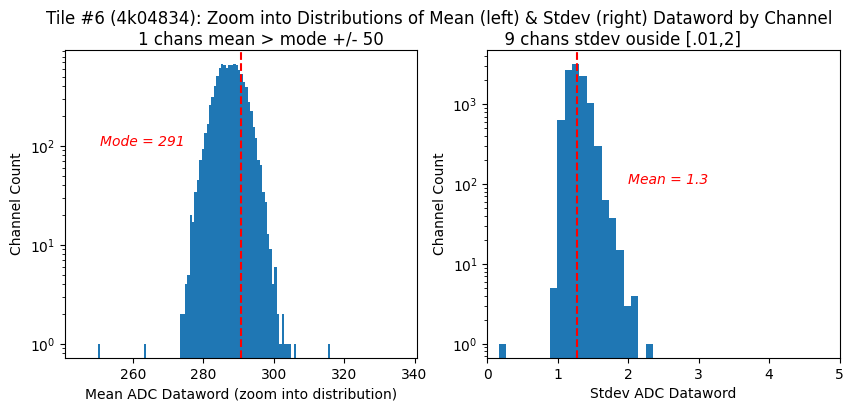

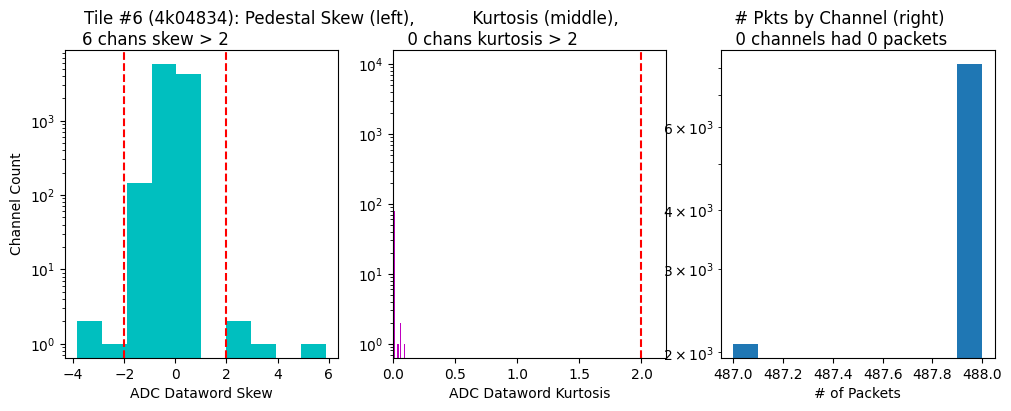

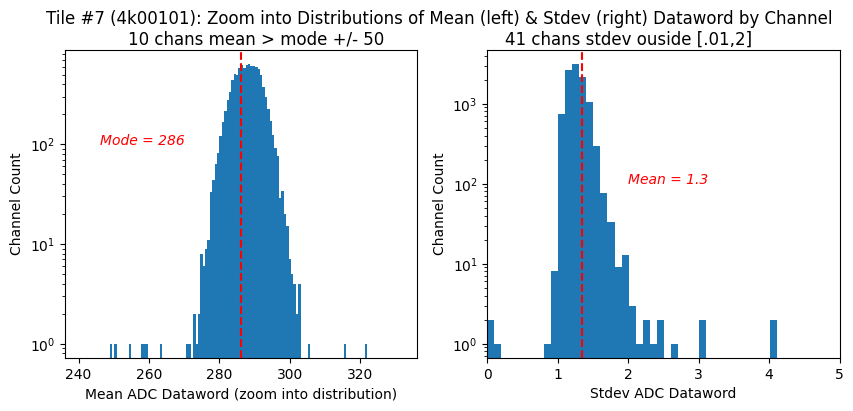

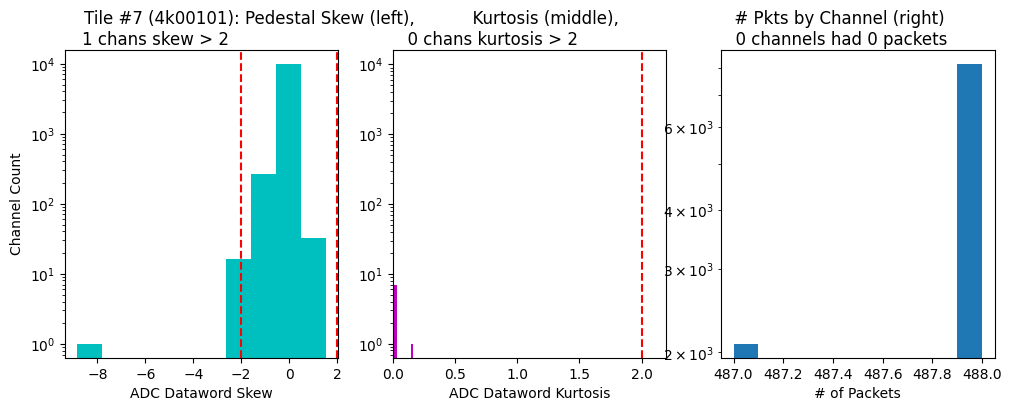

In [5]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)
    